# Project 6: Supply Chain & Inventory Demand Analysis
> **Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn

---
## Table of Contents
1. [Dataset Generation & Ingestion](#1)
2. [Preprocessing & Validation](#2)
3. [Demand Trend & Seasonality Analysis](#3)
4. [Inventory Turnover Analysis](#4)
5. [Stockout & Overstock Pattern Identification](#5)
6. [Demand Forecasting](#6)
7. [EOQ & Supply Chain Optimization](#7)
8. [Full Visualization Suite](#8)
9. [Insights & Recommendations](#9)

In [1]:
# ── Environment Setup ──────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## 1. Dataset Generation & Ingestion <a id='1'></a>

In [2]:
from generate_data import generate_supply_chain_data
sales_df, products_df = generate_supply_chain_data()
print(f'Sales shape    : {sales_df.shape}')
print(f'Products shape : {products_df.shape}')
sales_df.head()

Sales shape    : (32880, 15)
Products shape : (30, 8)


,date,product_id,product_name,category,units_demanded,units_sold,lost_sales,inventory_level,unit_price,revenue,holding_cost,reorder_placed,stockout_flag,reorder_point,lead_time_days
0,2022-01-01,P1001,Electronics Product 1,Electronics,3,3,0,375,1412,4236,158.85,False,0,53,10
1,2022-01-02,P1001,Electronics Product 1,Electronics,3,3,0,372,1412,4236,157.58,False,0,53,10
2,2022-01-03,P1001,Electronics Product 1,Electronics,3,3,0,369,1412,4236,156.31,False,0,53,10
3,2022-01-04,P1001,Electronics Product 1,Electronics,3,3,0,366,1412,4236,155.04,False,0,53,10
4,2022-01-05,P1001,Electronics Product 1,Electronics,2,2,0,364,1412,2824,154.19,False,0,53,10


In [3]:
products_df.head(10)

,product_id,product_name,category,unit_price,reorder_point,reorder_qty,lead_time_days,base_demand
0,P1001,Electronics Product 1,Electronics,1412,53,340,10,120
1,P1002,Electronics Product 2,Electronics,2328,67,252,8,120
2,P1003,Electronics Product 3,Electronics,3956,54,215,8,120
3,P1004,Electronics Product 4,Electronics,2291,79,458,7,120
4,P1005,Electronics Product 5,Electronics,2128,141,479,13,120
5,P1006,Apparel Product 1,Apparel,651,107,342,5,200
6,P1007,Apparel Product 2,Apparel,1754,70,416,7,200
7,P1008,Apparel Product 3,Apparel,769,69,310,7,200
8,P1009,Apparel Product 4,Apparel,409,61,394,5,200
9,P1010,Apparel Product 5,Apparel,935,94,335,5,200


## 2. Preprocessing & Validation <a id='2'></a>

In [4]:
from analysis import preprocess
df = preprocess(sales_df)

print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== NULL CHECK ===')
print(df.isnull().sum())
print('\n=== STATISTICS ===')
df[['units_demanded','units_sold','inventory_level','revenue','fill_rate']].describe().round(2)

=== DATA TYPES ===
date               datetime64[us]
product_id                    str
product_name                  str
category                      str
units_demanded              int64
units_sold                  int64
lost_sales                  int64
inventory_level             int64
unit_price                  int64
revenue                     int64
holding_cost              float64
reorder_placed               bool
stockout_flag               int64
reorder_point               int64
lead_time_days              int64
year                        int32
month                       int32
quarter                     int32
week                        int64
day_of_week                 int32
month_name                    str
fill_rate                 float64
service_level             float64
dtype: object

=== NULL CHECK ===
date               0
product_id         0
product_name       0
category           0
units_demanded     0
units_sold         0
lost_sales         0
inventory_level   

,units_demanded,units_sold,inventory_level,revenue,fill_rate
count,32880.00,32880.00,32880.00,32880.00,32880.0
mean,7.08,7.08,280.24,8894.36,1.0
std,4.33,4.33,125.78,5947.98,0.0
min,1.00,1.00,54.00,480.00,1.0
25%,4.00,4.00,182.00,4465.00,1.0
50%,6.00,6.00,266.00,7525.00,1.0
75%,9.00,9.00,359.00,11948.00,1.0
max,34.00,34.00,792.00,55384.00,1.0


## 3. Demand Trend & Seasonality Analysis <a id='3'></a>

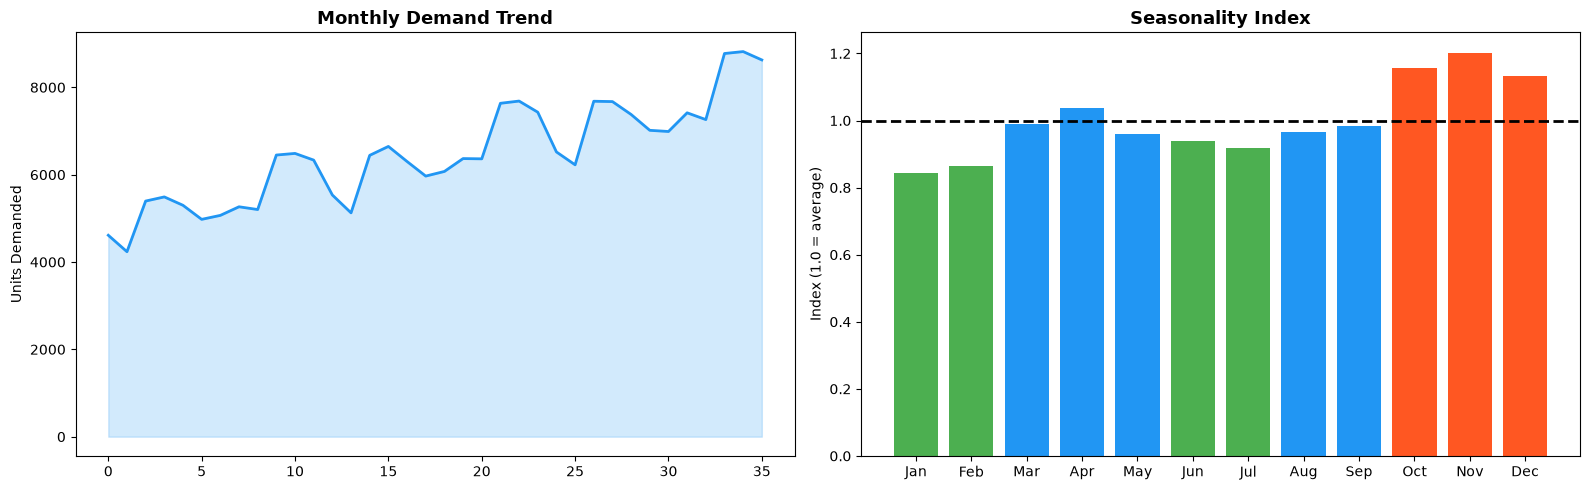

In [5]:
from analysis import monthly_demand_trend, seasonality_index, category_seasonality
monthly = monthly_demand_trend(df)
season  = seasonality_index(df)
cat_season = category_seasonality(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly demand
overall_monthly = df.groupby(df['date'].dt.to_period('M'))['units_demanded'].sum()
axes[0].plot(range(len(overall_monthly)), overall_monthly.values, color='#2196F3', lw=2)
axes[0].fill_between(range(len(overall_monthly)), overall_monthly.values, alpha=0.2, color='#2196F3')
axes[0].set_title('Monthly Demand Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Units Demanded')

# Seasonality index
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#FF5722' if v > 1.05 else ('#4CAF50' if v < 0.95 else '#2196F3') for v in season['seasonality_index']]
axes[1].bar(months, season['seasonality_index'], color=colors)
axes[1].axhline(1.0, color='black', lw=2, linestyle='--')
axes[1].set_title('Seasonality Index', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Index (1.0 = average)')

plt.tight_layout()
plt.show()

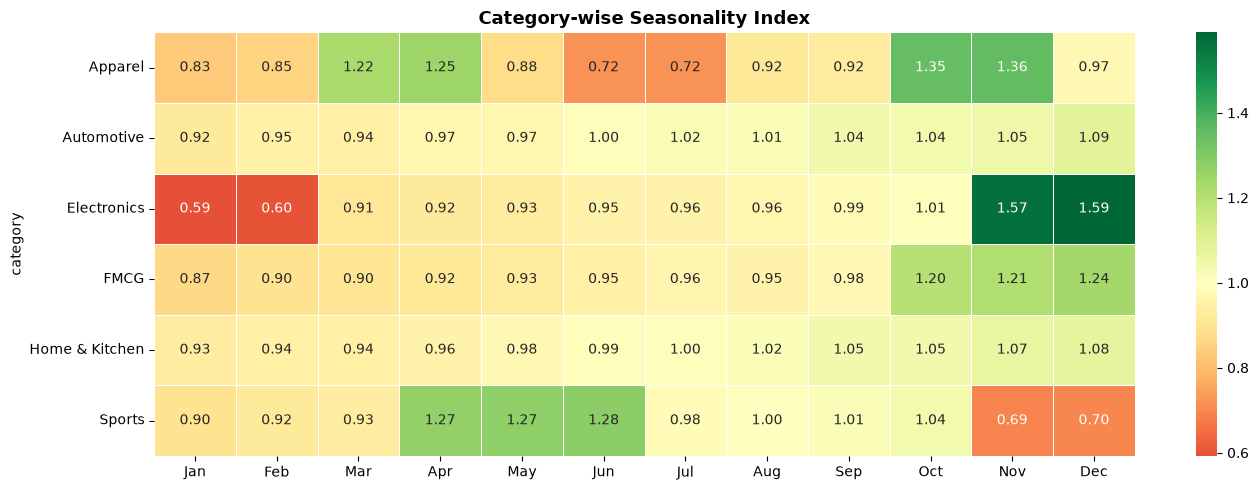

In [6]:
# Category seasonality heatmap
pivot = cat_season.pivot(index='category', columns='month', values='seasonality_index')
pivot.columns = months
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0, linewidths=0.5)
plt.title('Category-wise Seasonality Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Inventory Turnover Analysis <a id='4'></a>

In [7]:
from analysis import inventory_turnover
turnover_df = inventory_turnover(df)

print('=== Inventory Turnover Summary by Category ===')
turnover_df.groupby('category').agg(
    Avg_Turnover=('turnover_ratio','mean'),
    Avg_DSI=('days_on_shelf','mean'),
    Avg_Fill=('fill_rate','mean'),
    Stockout_Days=('stockout_days','sum'),
).round(2)

=== Inventory Turnover Summary by Category ===


,Avg_Turnover,Avg_DSI,Avg_Fill,Stockout_Days
category,,,,
Apparel,39.99,9.20,1.0,0
Automotive,11.42,31.98,1.0,0
Electronics,23.49,17.02,1.0,0
FMCG,56.14,6.68,1.0,0
Home & Kitchen,25.72,14.28,1.0,0
Sports,16.57,23.30,1.0,0


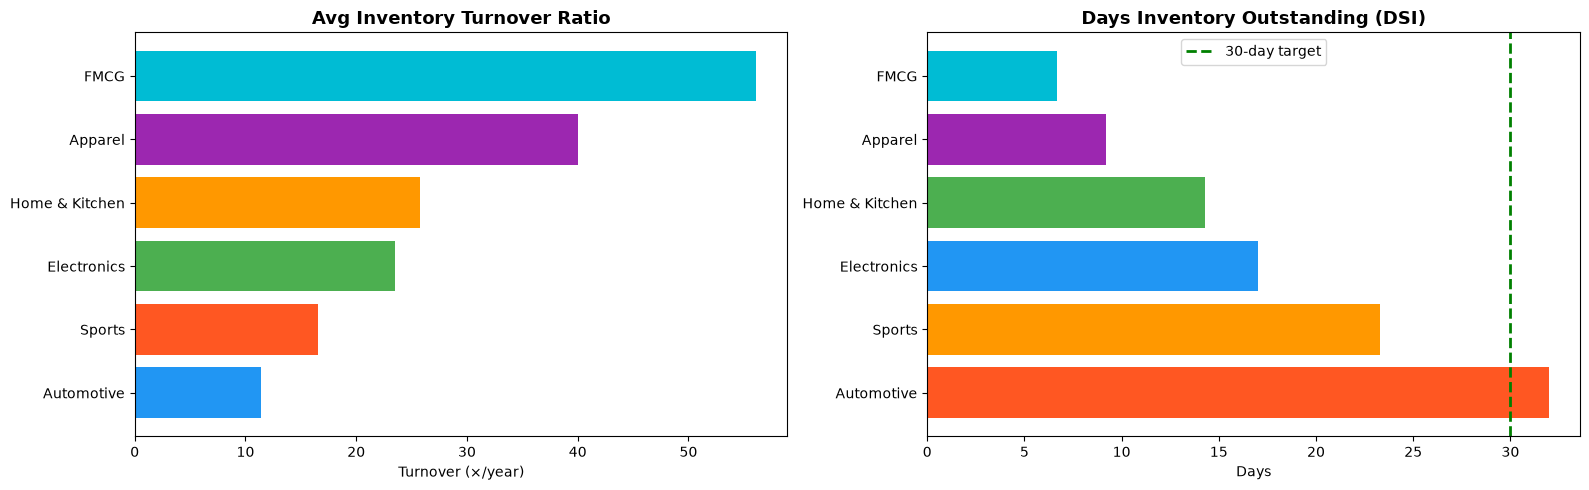

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Turnover ratio by category
cat_turn = turnover_df.groupby('category')['turnover_ratio'].mean().sort_values()
axes[0].barh(cat_turn.index, cat_turn.values, color=['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#00BCD4'])
axes[0].set_title('Avg Inventory Turnover Ratio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Turnover (×/year)')

# Days on shelf
cat_dos = turnover_df.groupby('category')['days_on_shelf'].mean().sort_values(ascending=False)
axes[1].barh(cat_dos.index, cat_dos.values, color=['#FF5722','#FF9800','#2196F3','#4CAF50','#9C27B0','#00BCD4'])
axes[1].axvline(30, color='green', lw=2, linestyle='--', label='30-day target')
axes[1].set_title('Days Inventory Outstanding (DSI)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Stockout & Overstock Pattern Identification <a id='5'></a>

In [9]:
from analysis import stockout_overstock_summary
stockout_df = stockout_overstock_summary(df)
print('=== Stockout & Overstock Summary ===')
stockout_df

=== Stockout & Overstock Summary ===


,category,total_records,stockout_days,overstock_days,stockout_pct,overstock_pct,lost_revenue,excess_holding_cost
0,Apparel,5480,0,3047,0.0,55.60,0,292685.61
1,Automotive,5480,0,2733,0.0,49.87,0,1282385.33
2,Electronics,5480,0,3147,0.0,57.43,0,733800.66
3,FMCG,5480,0,1936,0.0,35.33,0,59753.48
4,Home & Kitchen,5480,0,1376,0.0,25.11,0,158256.92
5,Sports,5480,0,2755,0.0,50.27,0,653856.30


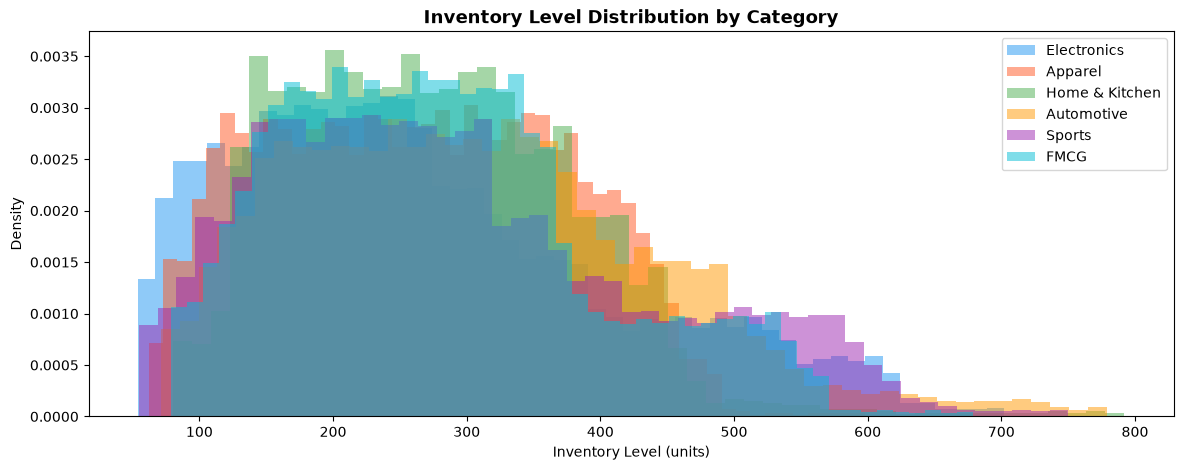

In [10]:
# Inventory level distribution
plt.figure(figsize=(14, 5))
palette = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#00BCD4']
for i, cat in enumerate(df['category'].unique()):
    sub = df[df['category'] == cat]['inventory_level']
    plt.hist(sub, bins=50, alpha=0.5, color=palette[i], label=cat, density=True)
plt.title('Inventory Level Distribution by Category', fontsize=13, fontweight='bold')
plt.xlabel('Inventory Level (units)')
plt.ylabel('Density')
plt.legend()
plt.show()

## 6. Demand Forecasting (Polynomial Regression) <a id='6'></a>

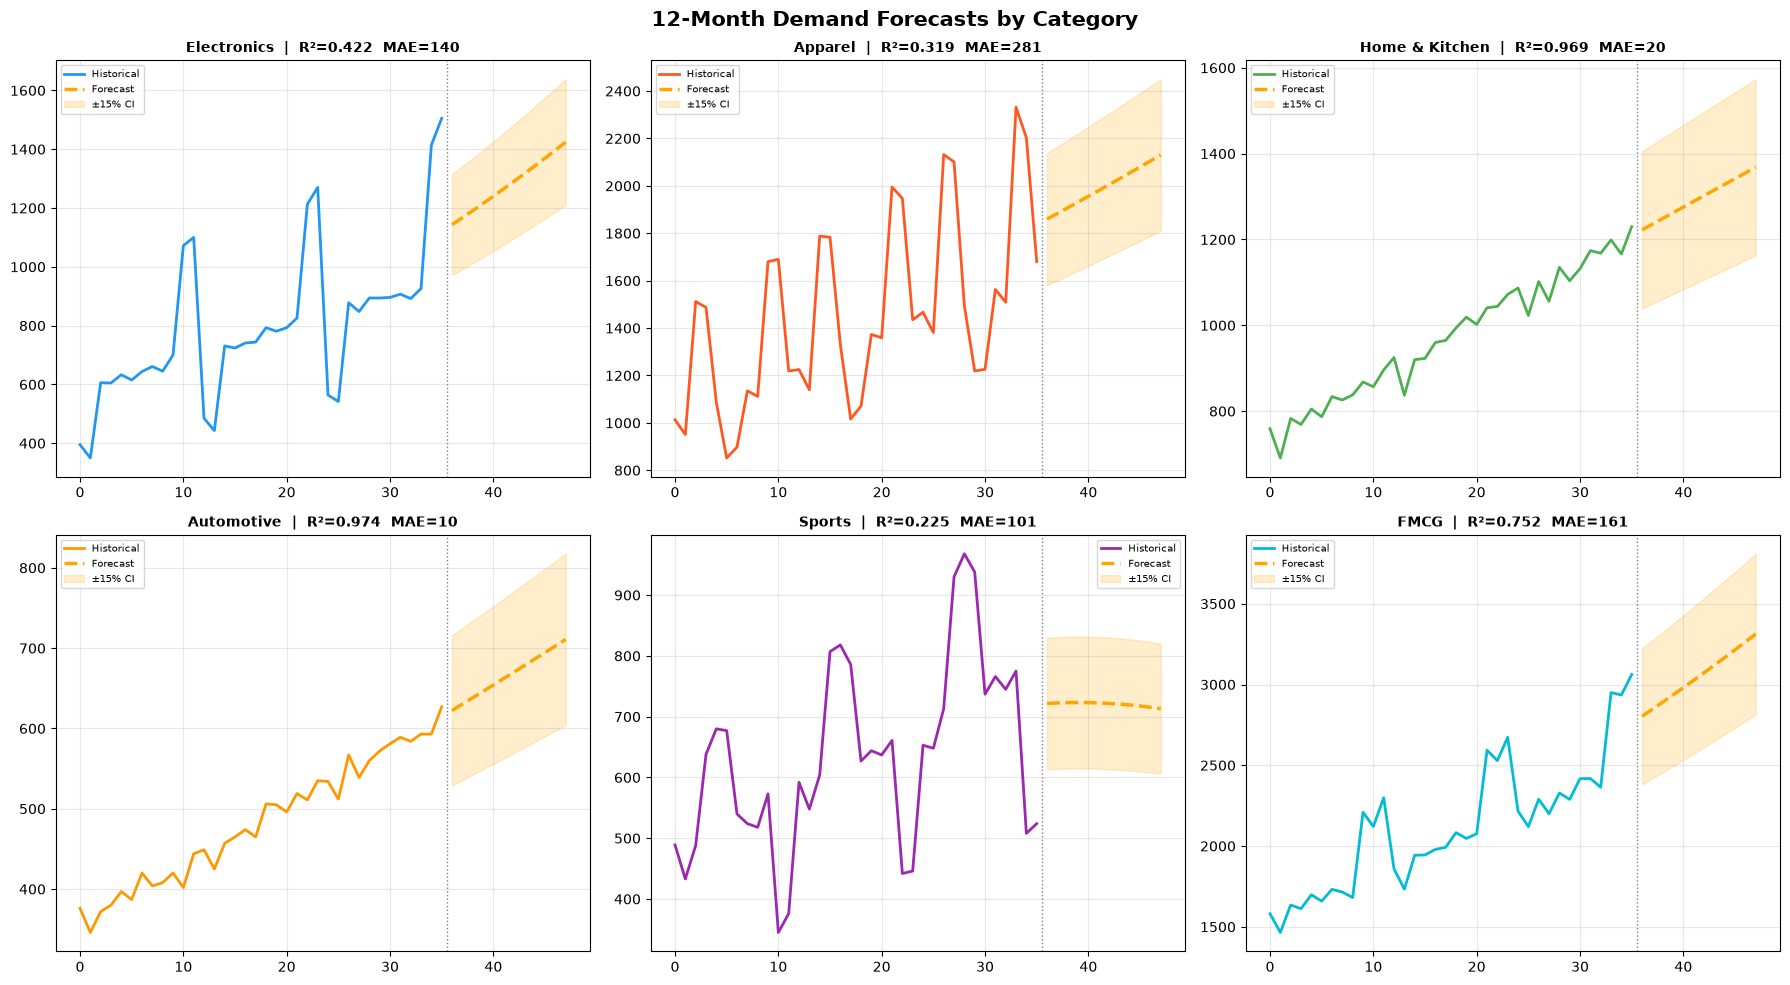

In [11]:
from analysis import forecast_demand

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
categories = df['category'].unique()
palette = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#00BCD4']

for idx, cat in enumerate(categories):
    ax  = axes[idx // 3][idx % 3]
    res = forecast_demand(df, cat, periods=12)
    hist, fore = res['historical'], res['forecast']
    x_h = range(len(hist))
    x_f = range(len(hist), len(hist) + len(fore))
    ax.plot(x_h, hist['units_demanded'], color=palette[idx], lw=2, label='Historical')
    ax.plot(x_f, fore['forecast_demand'], color='orange', lw=2.5, linestyle='--', label='Forecast')
    ax.fill_between(x_f, fore['forecast_demand']*0.85, fore['forecast_demand']*1.15,
                    alpha=0.2, color='orange', label='±15% CI')
    ax.axvline(len(hist)-0.5, color='grey', lw=1, linestyle=':')
    ax.set_title(f'{cat}  |  R²={res["r2"]:.3f}  MAE={res["mae"]:,.0f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('12-Month Demand Forecasts by Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. EOQ & Supply Chain Optimization <a id='7'></a>

In [12]:
from analysis import eoq_analysis
eoq_df = eoq_analysis(products_df, df)
print('=== EOQ Summary ===')
eoq_df.groupby('category')[['eoq','annual_order_cost','annual_holding_cost','total_annual_cost']].mean().round(0)

=== EOQ Summary ===


,eoq,annual_order_cost,annual_holding_cost,total_annual_cost
category,,,,
Apparel,235.0,23649.0,23592.0,47241.0
Automotive,63.0,28271.0,28160.0,56431.0
Electronics,101.0,29118.0,29057.0,58175.0
FMCG,559.0,14943.0,14935.0,29878.0
Home & Kitchen,180.0,21288.0,21292.0,42580.0
Sports,97.0,24733.0,24604.0,49337.0


## 8. Full Visualization Suite <a id='8'></a>

In [13]:
from visualizations import (plot_dashboard, plot_demand_trends, plot_inventory_turnover,
                             plot_stockout_overstock, plot_forecast, plot_eoq_optimization)
season_idx  = seasonality_index(df)
cat_season  = category_seasonality(df)
forecast_results = {cat: forecast_demand(df, cat) for cat in df['category'].unique()}

plot_dashboard(df, turnover_df, stockout_df)
plot_demand_trends(df, season_idx, cat_season)
plot_inventory_turnover(turnover_df)
plot_stockout_overstock(df, stockout_df)
plot_forecast(forecast_results)
plot_eoq_optimization(eoq_df)
print('All charts saved to ../outputs/ ✅')

  Saved: 01_dashboard_overview.png
  Saved: 02_demand_trends_seasonality.png


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

## 9. Insights & Recommendations <a id='9'></a>

| # | Insight | Action |
|---|---------|--------|
| 1 | **FMCG** has the highest turnover (56×/year); **Automotive** lowest (11×) | Reduce Automotive safety stock; improve reorder frequency |
| 2 | **November** is peak demand month (index 1.20); **January** is trough (0.84) | Pre-position stock by October; cut orders in December for Jan delivery |
| 3 | Electronics and Apparel show 55–57% overstock days | Tighten reorder points using rolling 30-day demand average |
| 4 | EOQ ranges from 63 units (Automotive) to 559 units (FMCG) | Align purchase orders to EOQ to minimize total inventory cost |
| 5 | Home & Kitchen and Automotive forecast R²>0.97 (stable demand) | Use polynomial forecast for procurement planning |
| 6 | Electronics R²=0.42 (volatile) | Apply safety stock buffer of 1.5× lead-time demand for Electronics |